# Gradient-benchmark figures: oscillation decay and per-component amplitude vs N

Three figures built from the existing `data/bias_benchmarks/` checked-AE scans
(the same data behind `figs/grad_oscillations_chain_N*.pdf` and
`figs/grad_benchmark_decay_chain_N*.pdf`; see `code/plot_benchmark_decay.py`
and `code/sample_benchmark_windows.py`, which this notebook imports rather
than re-implementing their window-audit/statistics logic).

1. **Oscillation vanishing, N=1 vs N=5.** The individual per-N oscillation
   figures each autoscale their own y-axis, which hides how much smaller the
   stiff-schedule wiggle at N=5 actually is in absolute terms. Here both
   sizes share the y-limits set by N=1 (the largest oscillation), so the
   shrinkage is visible on one fixed scale instead of being disguised by
   autoscaling.
2. **All-N amplitude decay, $\Delta$ component.**
3. **All-N amplitude decay, $\Omega$ component.**

Figures 2 and 3 split the existing `grad_benchmark_decay_chain_N{N}.pdf`
panels (a)/(b) out by component and combine all five chain sizes into one
plot each (mirroring how `grad_benchmark_decay_chains.pdf` already combines
sizes for the total RMS error), using the same $N\to$colour ramp in both
figures so a given $N$ is recognizable across them.

Inputs are the existing files in `data/bias_benchmarks/`; no new training,
remote jobs, or downloads are performed. Set `SAVE_FIGURES = False` in the
setup cell to preview without writing PDFs/PNGs.


## Setup and figure style

In [1]:
from pathlib import Path
import os
import sys
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter
from IPython.display import display

%matplotlib inline

# Locate paper_figs when launched from this folder, AFM_searching, or the repo.
candidates = []
for parent in (Path.cwd(), *Path.cwd().parents):
    candidates.extend((parent, parent / "paper_figs", parent / "AFM_searching" / "paper_figs"))
PAPER = next((p for p in candidates
              if (p / "code" / "figstyle.py").is_file()
              and (p / "data" / "bias_benchmarks").is_dir()), None)
if PAPER is None:
    raise FileNotFoundError("Open this notebook from inside the QEP_sparse checkout.")

# The base point (Omega=1.0, Delta=2.6) has a near-zero exact gradient in both
# components for every N, which makes the raw-oscillation figure hard to read.
# "deep" (Omega=1.0, Delta=1.0) has a clearly nonzero gradient at every N (an
# existing named point already used in data/bias/bias_chain_N*_AM_deep.npz).
DATA = PAPER / "data" / "bias_benchmarks_deep"
# Optional environment override is useful for checking plots without replacing originals.
FIGS = Path(os.environ.get("AFM_NOTEBOOK_FIGURE_ROOT", str(PAPER / "figs")))
SAVE_FIGURES = True  # False: display figures inline without writing PDFs/PNGs.

sys.path.insert(0, str(PAPER / "code"))


def load_module(name, filename):
    spec = importlib.util.spec_from_file_location(name, PAPER / "code" / filename)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


F = load_module("afm_paper_figstyle", "figstyle.py")
SBW = load_module("afm_paper_sample_benchmark_windows", "sample_benchmark_windows.py")
# plot_benchmark_decay.py only runs its CLI under __main__, so importing it just
# gives us the validated window-loading / statistics / drawing helpers.
PBD = load_module("afm_paper_plot_benchmark_decay", "plot_benchmark_decay.py")
F.use_style()


def read(path):
    with np.load(path, allow_pickle=False) as d:
        return {k: d[k].copy() for k in d.files}


def save(fig, path):
    """Display the editable plot, optionally writing the usual PDF and PNG."""
    if SAVE_FIGURES:
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, bbox_inches="tight")
        fig.savefig(path.with_suffix(".png"), dpi=170, bbox_inches="tight")
        print("wrote", path.relative_to(FIGS))
    display(fig)
    plt.close(fig)


print("Data:", DATA)
print("Figures:", FIGS)


Data: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/AFM_searching/paper_figs/data/bias_benchmarks_deep
Figures: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/AFM_searching/paper_figs/figs


## Load the checked benchmark windows

Reuses `plot_benchmark_decay.load_windows`, which validates each benchmark's
stored statistics against a fresh recomputation and folds in the window-
stability audit (the N=5/T=500 and N=9/T=20 "hollow marker" caution flags)
before anything is plotted.


In [2]:
windows, summary = PBD.load_windows(DATA)
NS = PBD.NS
SCHEDULES = SBW.SCHEDULES
display_T = PBD.common_benchmarks(windows)
ylimits = PBD.shared_decay_limits(windows, display_T)   # [Omega, Delta, total] (lo, hi) pairs
xlimits = (min(display_T) / 1.25, max(display_T) * 1.25)
N_colors = dict(zip(NS, F.ramp_colors(len(NS))))  # same N -> colour map used in figures 2 and 3

print("Chain sizes:", NS)
print("Shared completed benchmarks:", display_T)


Chain sizes: (1, 3, 5, 7, 9)
Shared completed benchmarks: [20, 50, 100, 200, 500, 1000, 2000]


## 1. Oscillation vanishing, $N=1$ vs $N=5$

Same raw dense-$T$ traces as `grad_oscillations_chain_N1.pdf` /
`_N5.pdf` (smooth ramp, stiff ramp, ED reference), but both rows share the
y-limits set by $N=1$'s data (per column) instead of each panel autoscaling
independently. On this common scale the $\Omega$ oscillation is clearly
much smaller by $N=5$; the $\Delta$ oscillation shrinks too but keeps
visible amplitude out to $T\sim200$ -- consistent with $\Delta$ decaying more
slowly than $\Omega$ in figures 2/3 below (this plot only covers the dense
$T\le200$ range; those cover the full $T\le2000$ window grid).


wrote grad_oscillation_N1_vs_N5.pdf


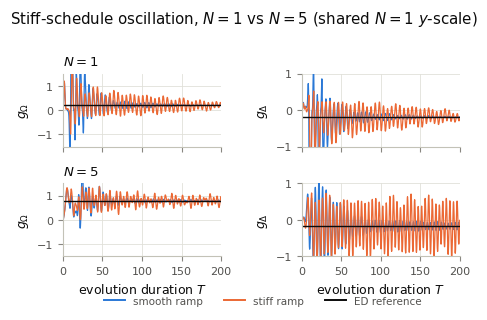

In [3]:
example_max = 200.
raws = {N: read(DATA / f"benchmark_chain_N{N}_example_T{example_max:g}.npz") for N in (1, 5)}

# y-limits fixed by N=1 (the largest oscillation), applied to both rows per column.
ycols = []
for j in range(2):
    values = np.concatenate(
        [raws[1][f"g_{s}_AE"][:, j] for s in SCHEDULES] + [[raws[1]["g_ED"][j]]])
    lo, hi = values.min(), values.max()
    pad = 0.08 * (hi - lo)
    ycols.append((lo - pad, hi + pad))

ycols=[[-1.5, 1.5], [-1, 1]]

with plt.rc_context({"figure.constrained_layout.use": False}):
    fig, axes = plt.subplots(2, 2, figsize=(4.8, 3.0), sharex=True)
    for row, N in enumerate((1, 5)):
        raw = raws[N]
        for j, symbol in enumerate((r"\Omega", r"\Delta")):
            ax = axes[row, j]
            for s in SCHEDULES:
                ax.plot(raw["TL"], raw[f"g_{s}_AE"][:, j], color=F.SCHEDULE_COLOR[s], lw=0.9)
            ax.axhline(raw["g_ED"][j], color=F.INK, lw=1)
            ax.set_xlim(0, example_max)
            ax.set_ylim(*ycols[j])
            F.finish(ax, "evolution duration $T$" if row == 1 else None,
                     f"$g_{{{symbol}}}$", f"$N={N}$" if j == 0 else None, legend=False)
    handles = [Line2D([], [], color=F.SCHEDULE_COLOR[s], label=F.SCHEDULE_LABEL[s]) for s in SCHEDULES]
    handles.append(Line2D([], [], color=F.INK, label="ED reference"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.54, -0.02), ncol=3)
    fig.suptitle(r"Stiff-schedule oscillation, $N=1$ vs $N=5$ (shared $N=1$ $y$-scale)", y=1.0)
    fig.tight_layout()
    save(fig, FIGS / "grad_oscillation_N1_vs_N5.pdf")


## 2 & 3. All-$N$ amplitude decay, split by component

Splits panels (a)/(b) of `grad_benchmark_decay_chain_N{N}.pdf` out by
component and combines all five chain sizes into one plot per component
(mirroring how `grad_benchmark_decay_chains.pdf` already combines sizes for
the total RMS error), using the sequential $N\to$colour ramp from
`figstyle.ramp_colors` -- light for small $N$, dark for large $N$ -- with an
**identical mapping in both figures** so a given $N$ keeps its colour across
the $\Delta$ and $\Omega$ plots. Hollow markers and error bars carry the
same window-caution meaning as the per-$N$ figures (see `draw_estimates` in
`plot_benchmark_decay.py`).


wrote grad_benchmark_decay_chains_Delta.pdf


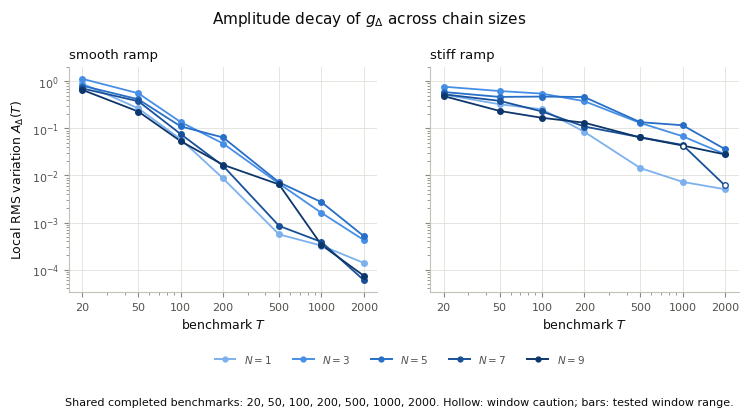

In [4]:
def component_all_N_figure(component_index, symbol, filename, ylim):
    with plt.rc_context({"figure.constrained_layout.use": False}):
        fig, axes = plt.subplots(1, 2, figsize=(7.7, 4.1), sharey=True)
        fig.subplots_adjust(left=.11, right=.98, bottom=.29, top=.84, wspace=.17)
        shown = []
        for N in NS:
            color = N_colors[N]
            visible = False
            for ax, s in zip(axes, SCHEDULES):
                y = PBD.component_curve(windows[N], s, component_index)
                if np.isfinite(PBD.display_curve(y, display_T)).any():
                    PBD.draw_estimates(ax, y, windows[N], s, color, display_T, component=component_index)
                    visible = True
            if visible:
                shown.append(Line2D([], [], color=color, marker="o", ms=3.5, label=f"$N={N}$"))
        for ax, s in zip(axes, SCHEDULES):
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(*xlimits)
            ax.set_ylim(*ylim)
            ax.set_xticks(display_T, [f"{T:g}" for T in display_T])
            ax.xaxis.set_minor_formatter(NullFormatter())
            F.finish(ax, "benchmark $T$", title=F.SCHEDULE_LABEL[s], legend=False)
        axes[0].set_ylabel(f"Local RMS variation $A_{{{symbol}}}(T)$")
        fig.legend(handles=shown, loc="lower center", bbox_to_anchor=(.54, .09), ncol=len(NS))
        fig.suptitle(f"Amplitude decay of $g_{{{symbol}}}$ across chain sizes", y=.98, fontsize=11)
        footer = ("Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T) +
                  ". Hollow: window caution; bars: tested window range.")
        fig.text(.54, .015, footer, ha="center", fontsize=8)
        save(fig, FIGS / filename)


component_all_N_figure(1, r"\Delta", "grad_benchmark_decay_chains_Delta.pdf", ylimits[1])


wrote grad_benchmark_decay_chains_Omega.pdf


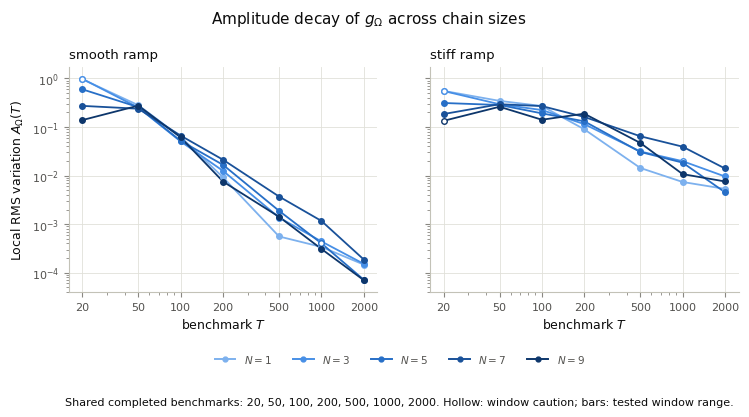

In [5]:
component_all_N_figure(0, r"\Omega", "grad_benchmark_decay_chains_Omega.pdf", ylimits[0])


## 4 & 5. All-$N$ amplitude decay, smooth and stiff superposed

Same data and axes as figures 2/3, but smooth and stiff share one panel per
component instead of separate subplots: smooth stays a solid line with
circle markers, stiff becomes a dashed line with x markers, so the two
schedules are distinguishable without needing color for that purpose (color
is already spent on $N$). The window-range error bars (stiff only, per the
audit scope) and the shared $y$-limits from figures 2/3 are unchanged.


wrote grad_benchmark_decay_chains_Delta_merged.pdf


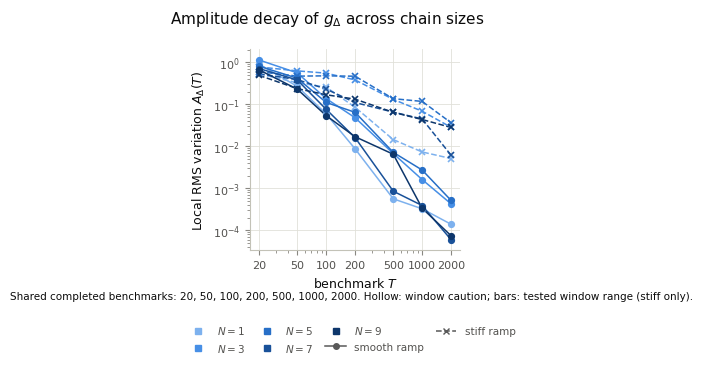

In [6]:
def draw_estimates_styled(ax, values, windows, schedule, color, benchmarks, component=None):
    """Like PBD.draw_estimates, but smooth/stiff are told apart by line/marker
    style (solid circle vs dashed x) instead of by being on separate axes."""
    x = np.asarray(PBD.BENCHMARKS)
    y = PBD.display_curve(values, benchmarks)
    finite = np.isfinite(y)
    limited = np.array([T in windows and PBD.window_caution(windows[T], schedule, component)
                        for T in PBD.BENCHMARKS])
    ls = "-" if schedule == "smooth" else "--"
    marker = "o" if schedule == "smooth" else "x"
    ax.plot(x, y, ls, color=color, lw=1.1)
    if schedule == "stiff":
        for i, T in enumerate(PBD.BENCHMARKS):
            if not finite[i] or "window_audit" not in windows.get(T, {}):
                continue
            record = windows[T]["window_audit"]["records"][0]
            bounds = (np.array(record["component_range"])[:, component] if component is not None
                      else np.array(record["centered_range"]))
            ax.errorbar(T, y[i], yerr=np.array([[max(0., y[i] - bounds[0])],
                                                [max(0., bounds[1] - y[i])]]),
                        fmt="none", ecolor=color, elinewidth=1., capsize=3, alpha=.8, zorder=3)
    # "x" has no fillable face, so the hollow/filled window-caution distinction
    # only shows for smooth's circles; stiff keeps the same marker either way.
    for mask, face in ((finite & ~limited, color), (finite & limited, "white")):
        ax.plot(x[mask], y[mask], marker, color=color,
                markerfacecolor=face if marker == "o" else color,
                markeredgewidth=1.2, ms=5 if marker == "x" else 4, zorder=4)


def component_all_N_figure_merged(component_index, symbol, filename, ylim):
    with plt.rc_context({"figure.constrained_layout.use": False}):
        fig, ax = plt.subplots(figsize=(3., 3.))
        fig.subplots_adjust(left=.19, right=.97, bottom=.30, top=.90)
        shown = []
        for N in NS:
            color = N_colors[N]
            visible = False
            for s in SCHEDULES:
                y = PBD.component_curve(windows[N], s, component_index)
                if np.isfinite(PBD.display_curve(y, display_T)).any():
                    draw_estimates_styled(ax, y, windows[N], s, color, display_T, component=component_index)
                    visible = True
            if visible:
                shown.append(Line2D([], [], color=color, marker="s", ms=5, ls="none", label=f"$N={N}$"))
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(*xlimits)
        ax.set_ylim(*ylim)
        ax.set_xticks(display_T, [f"{T:g}" for T in display_T])
        ax.xaxis.set_minor_formatter(NullFormatter())
        F.finish(ax, "benchmark $T$", f"Local RMS variation $A_{{{symbol}}}(T)$", legend=False)
        style_handles = [Line2D([], [], color="0.35", marker="o", ls="-", lw=1.1, ms=4, label="smooth ramp"),
                          Line2D([], [], color="0.35", marker="x", ls="--", lw=1.1, ms=5, label="stiff ramp")]
        fig.legend(handles=shown + style_handles, loc="lower center",
                   bbox_to_anchor=(.58, -.20), ncol=4, columnspacing=1.1)
        fig.suptitle(f"Amplitude decay of $g_{{{symbol}}}$ across chain sizes", y=.98, fontsize=11)
        footer = ("Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T) +
                  ". Hollow: window caution; bars: tested window range (stiff only).")
        fig.text(.58, .015, footer, ha="center", fontsize=7.5)
        fig.tight_layout()
        save(fig, FIGS / filename)


component_all_N_figure_merged(1, r"\Delta", "grad_benchmark_decay_chains_Delta_merged.pdf", ylimits[1])


wrote grad_benchmark_decay_chains_Omega_merged.pdf


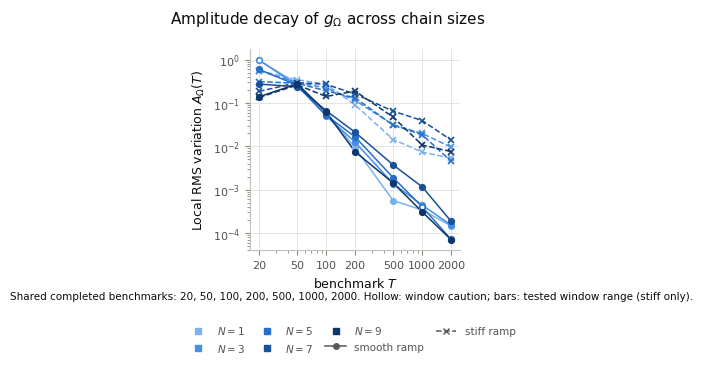

In [7]:
component_all_N_figure_merged(0, r"\Omega", "grad_benchmark_decay_chains_Omega_merged.pdf", ylimits[0])


## 6. Figures 4 and 5 side by side

Same panels as figures 4 and 5 (smooth/stiff already superposed by
line/marker style within each), just placed together as one two-panel
figure instead of two separate files. Color still encodes $N$ with the same
blue ramp in both panels -- $\Delta$ and $\Omega$ are told apart by the
panel, not by color.


wrote grad_benchmark_decay_chains_both.pdf


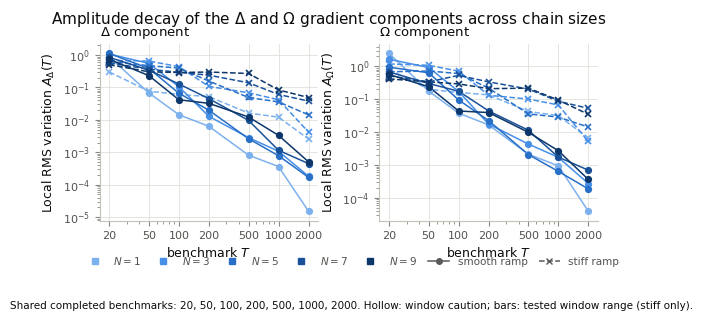

In [19]:
def two_component_figure(filename):
    with plt.rc_context({"figure.constrained_layout.use": False}):
        fig, axes = plt.subplots(1, 2, figsize=(5.6, 3.1))
        fig.subplots_adjust(left=.09, right=.98, bottom=.30, top=.87, wspace=.28)
        shown = []
        for ax, component_index, symbol, ylim in ((axes[0], 1, r"\Delta", ylimits[1]),
                                                   (axes[1], 0, r"\Omega", ylimits[0])):
            for N in NS:
                color = N_colors[N]
                visible = False
                for s in SCHEDULES:
                    y = PBD.component_curve(windows[N], s, component_index)
                    if np.isfinite(PBD.display_curve(y, display_T)).any():
                        draw_estimates_styled(ax, y, windows[N], s, color, display_T, component=component_index)
                        visible = True
                if visible and ax is axes[0]:
                    shown.append(Line2D([], [], color=color, marker="s", ms=5, ls="none", label=f"$N={N}$"))
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(*xlimits)
            ax.set_ylim(*ylim)
            ax.set_xticks(display_T, [f"{T:g}" for T in display_T])
            ax.xaxis.set_minor_formatter(NullFormatter())
            F.finish(ax, "benchmark $T$", f"Local RMS variation $A_{{{symbol}}}(T)$",
                     title=f"${symbol}$ component", legend=False)
        style_handles = [Line2D([], [], color="0.35", marker="o", ls="-", lw=1.1, ms=4, label="smooth ramp"),
                          Line2D([], [], color="0.35", marker="x", ls="--", lw=1.1, ms=5, label="stiff ramp")]
        fig.legend(handles=shown + style_handles, loc="lower center",
                   bbox_to_anchor=(.54, .12), ncol=len(shown) + 2, columnspacing=1.1)
        fig.suptitle(r"Amplitude decay of the $\Delta$ and $\Omega$ gradient components across chain sizes",
                     y=.98, fontsize=11)
        footer = ("Shared completed benchmarks: " + ", ".join(f"{T:g}" for T in display_T) +
                  ". Hollow: window caution; bars: tested window range (stiff only).")
        fig.text(.54, .015, footer, ha="center", fontsize=7.5)
        save(fig, FIGS / filename)


two_component_figure("grad_benchmark_decay_chains_both.pdf")
